# Кроп фигуры человека (OpenCV + YOLO-fallback)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00


In [3]:
import os
from pathlib import Path

IMAGES_DIR = Path('/content/drive/MyDrive/vkr/images')
OUT_DIR    = Path('/content/crops')
META_CSV   = Path('/content/crop_meta.csv')
ZIP_PATH   = Path('/content/drive/MyDrive/vkr/crops.zip')

OUT_SIZE   = 384
PAD_PCT    = 0.08
YOLO_CONF  = 0.10
YOLO_MODEL = 'yolov8n.pt'

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(IMAGES_DIR, IMAGES_DIR.exists())

/content/drive/MyDrive/vkr/images True


In [4]:
EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}
image_paths = sorted([p for p in IMAGES_DIR.rglob('*') if p.suffix.lower() in EXTS])
print(f'найдено: {len(image_paths)}')
assert len(image_paths) > 0

найдено: 8203


In [5]:
from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

model = YOLO(YOLO_MODEL)
PERSON_CLS = 0

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
device: cpu


In [6]:
import numpy as np
import cv2
from PIL import Image

CLAHE_DETECT = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(16, 16))

def enhance_for_detection(pil_img):
    arr = np.array(pil_img.convert('L'))
    arr = cv2.GaussianBlur(arr, (3, 3), 0)
    arr = CLAHE_DETECT.apply(arr)
    rgb = cv2.cvtColor(arr, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(rgb)

def yolo_bbox(pil_img):
    arr = np.array(pil_img.convert('RGB'))
    res = model.predict(arr, conf=YOLO_CONF, classes=[PERSON_CLS], device=device, verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0:
        return None
    boxes = res.boxes.xyxy.cpu().numpy()
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return tuple(map(float, boxes[areas.argmax()]))

def contour_bbox(pil_img):
    g = np.array(pil_img.convert('L'))
    H, W = g.shape
    mh, mw = int(H * 0.03), int(W * 0.03)
    inner = g[mh:H-mh, mw:W-mw]
    Hi, Wi = inner.shape
    img_area = Hi * Wi

    bw = cv2.adaptiveThreshold(inner, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, 51, 10)
    bw = cv2.medianBlur(bw, 3)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, k, iterations=1)

    n_lbl, _, stats, _ = cv2.connectedComponentsWithStats(bw, 8)
    if n_lbl <= 1:
        return None

    keep = []
    for i in range(1, n_lbl):
        x = int(stats[i, cv2.CC_STAT_LEFT])
        y = int(stats[i, cv2.CC_STAT_TOP])
        w = int(stats[i, cv2.CC_STAT_WIDTH])
        h = int(stats[i, cv2.CC_STAT_HEIGHT])
        a = int(stats[i, cv2.CC_STAT_AREA])
        bbox_area = w * h
        if bbox_area < 0.0005 * img_area: continue
        if w > 0.92 * Wi and h > 0.92 * Hi: continue
        if max(w, h) / max(min(w, h), 1) > 12: continue
        if a < 0.005 * bbox_area: continue
        keep.append((x, y, x + w, y + h, bbox_area))

    if not keep:
        return None

    keep.sort(key=lambda t: -t[4])
    anchor = keep[0]
    ax_c = (anchor[0] + anchor[2]) / 2
    ay_c = (anchor[1] + anchor[3]) / 2
    a_size = max(anchor[2] - anchor[0], anchor[3] - anchor[1])
    D = max(a_size * 3.0, 0.12 * max(Hi, Wi))

    merged = [anchor]
    for c in keep[1:]:
        cx = (c[0] + c[2]) / 2
        cy = (c[1] + c[3]) / 2
        if abs(cx - ax_c) < D and abs(cy - ay_c) < D:
            merged.append(c)

    xs1 = min(c[0] for c in merged); ys1 = min(c[1] for c in merged)
    xs2 = max(c[2] for c in merged); ys2 = max(c[3] for c in merged)
    return (float(xs1 + mw), float(ys1 + mh), float(xs2 + mw), float(ys2 + mh))

def pad_to_square(pil_img, fill=(255, 255, 255)):
    w, h = pil_img.size
    s = max(w, h)
    canvas = Image.new('RGB', (s, s), fill)
    canvas.paste(pil_img, ((s - w) // 2, (s - h) // 2))
    return canvas

def crop_with_padding(pil_img, bbox, pad_pct=PAD_PCT):
    W, H = pil_img.size
    x1, y1, x2, y2 = bbox
    bw, bh = x2 - x1, y2 - y1
    px, py = bw * pad_pct, bh * pad_pct
    x1 = max(0, int(x1 - px));  y1 = max(0, int(y1 - py))
    x2 = min(W, int(x2 + px));  y2 = min(H, int(y2 + py))
    return pil_img.crop((x1, y1, x2, y2))

def process(pil_img):
    pil_rgb = pil_img.convert('RGB')
    enh = enhance_for_detection(pil_rgb)
    bb = contour_bbox(enh); src = 'contour'
    if bb is None:
        bb = yolo_bbox(enh); src = 'yolo'
    if bb is None:
        bb = (0, 0, pil_rgb.size[0], pil_rgb.size[1]); src = 'whole'
    cropped = crop_with_padding(pil_rgb, bb)
    squared = pad_to_square(cropped)
    resized = squared.resize((OUT_SIZE, OUT_SIZE), Image.BILINEAR)
    return resized, src, bb

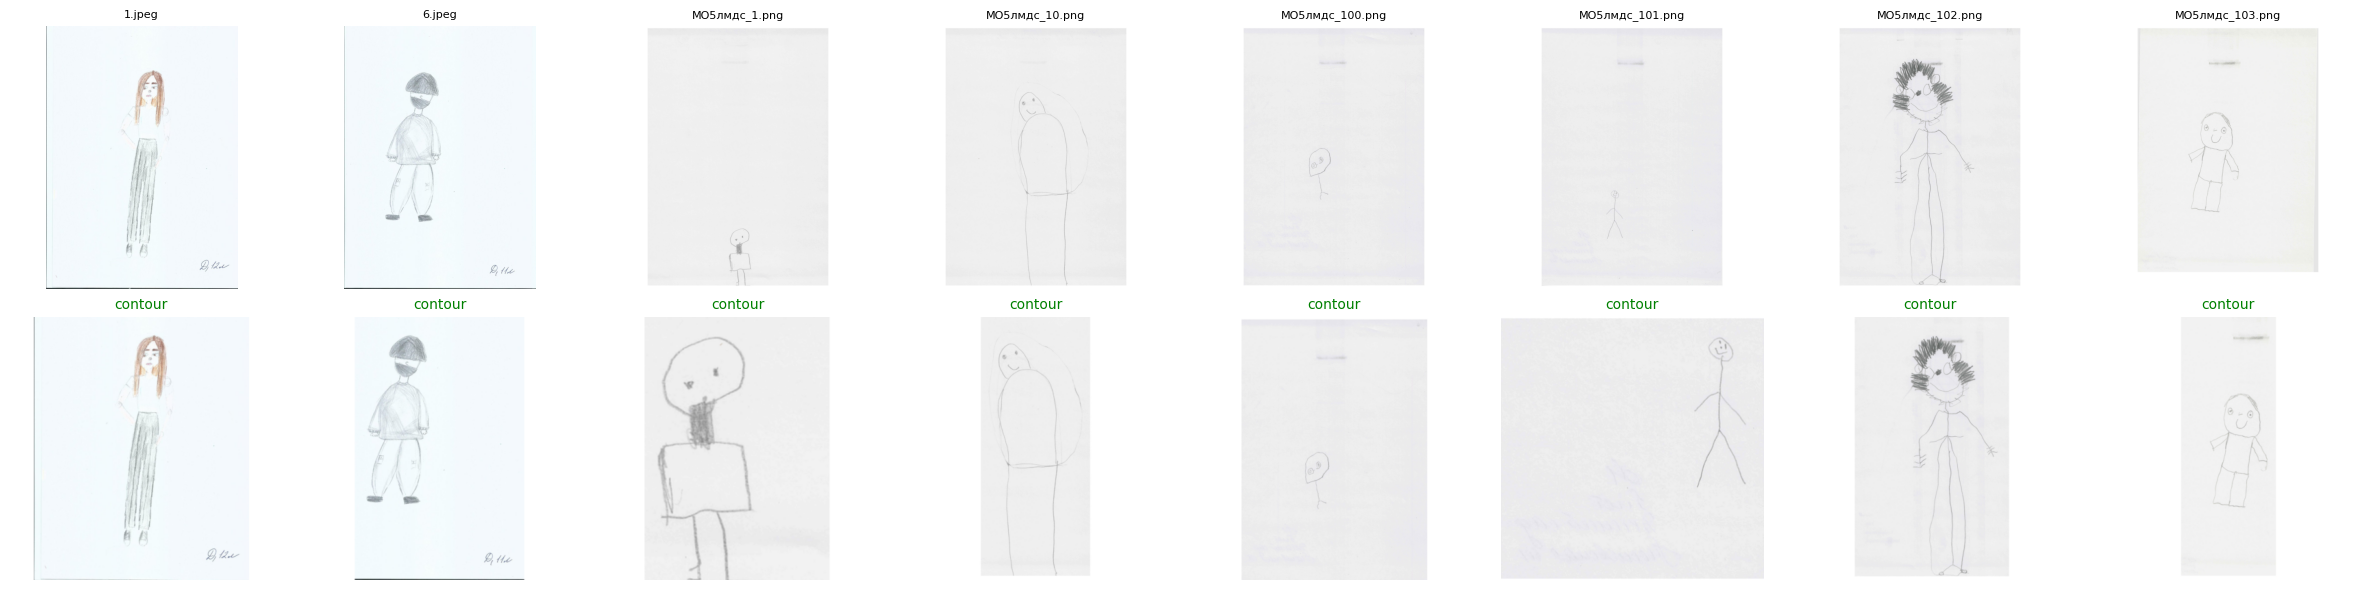

In [7]:
import matplotlib.pyplot as plt

sample = image_paths[:8]
fig, axes = plt.subplots(2, 8, figsize=(24, 6))
for j, p in enumerate(sample):
    src_img = Image.open(p)
    out, tag, bb = process(src_img)
    axes[0, j].imshow(src_img); axes[0, j].set_title(p.name[:18], fontsize=8); axes[0, j].axis('off')
    axes[1, j].imshow(out); axes[1, j].set_title(tag, fontsize=10,
                                                  color='green' if tag == 'contour' else 'orange')
    axes[1, j].axis('off')
plt.tight_layout(); plt.show()

In [8]:
import csv
from tqdm.auto import tqdm
from collections import Counter

stats = Counter()
rows = []

for p in tqdm(image_paths):
    try:
        img = Image.open(p)
        out, src, bb = process(img)
        out_path = OUT_DIR / (p.stem + '.png')
        out.save(out_path, 'PNG')
        stats[src] += 1
        rows.append({
            'src_file': p.name, 'out_file': out_path.name, 'bbox_source': src,
            'x1': round(bb[0], 1), 'y1': round(bb[1], 1),
            'x2': round(bb[2], 1), 'y2': round(bb[3], 1),
            'orig_w': img.size[0], 'orig_h': img.size[1],
        })
    except Exception as e:
        stats['error'] += 1
        rows.append({'src_file': p.name, 'out_file': '', 'bbox_source': f'error:{e}',
                     'x1': 0, 'y1': 0, 'x2': 0, 'y2': 0, 'orig_w': 0, 'orig_h': 0})

with open(META_CSV, 'w', encoding='utf-8', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader(); w.writerows(rows)

total = sum(stats.values())
for k, v in stats.most_common():
    print(f'{k:10s} {v:6d}  ({100 * v / total:.1f}%)')
print('total:', total)

  0%|          | 0/8203 [00:00<?, ?it/s]

contour      8193  (99.9%)
whole           5  (0.1%)
error           4  (0.0%)
yolo            1  (0.0%)
total: 8203


In [10]:
print("!")

!


In [11]:
import shutil
shutil.make_archive(str(ZIP_PATH).replace('.zip', ''), 'zip', OUT_DIR)
shutil.copy(META_CSV, '/content/drive/MyDrive/vkr/crop_meta.csv')
print('zip:', ZIP_PATH, ZIP_PATH.stat().st_size / 1e6, 'МБ')

zip: /content/drive/MyDrive/vkr/crops.zip 501.729524 МБ
